# Orbit ODE Notebook

## 1) Imports and Global Constants

In [26]:
using LinearAlgebra
using Statistics
using DifferentialEquations
using StaticArrays
using MeshCat
using GeometryBasics
using CoordinateTransformations
using Colors
using Rotations

const MU = 398600.4418      # km^3/s^2 , earths gravitation parameter
const RE = 6378.1363        # km, earth radius
const J2 = 1.08262668e-3    # earth oblateness constant, important to us, sunsync


0.00108262668

## 2) Dynamics Functions

In [27]:
function drag_accel_km(r_km, v_kms)
    r_m = 1000.0 .* r_km
    v_ms = 1000.0 .* v_kms

    rn_m = norm(r_m)
    h = rn_m - RE*1000.0

    rho = rho0 * exp(-(h - h0)/H_atm)

    w = SVector(0.0, 0.0, wE)
    v_atm = cross(w, r_m)
    v_rel = v_ms - v_atm
    vrel = norm(v_rel)

    aD_ms2 = -0.5 * rho * Bc * vrel * v_rel
    return aD_ms2 ./ 1000.0   # km/s^2
end

# p is a NamedTuple with field :drag (Bool)
# p = (drag=false,)  →  J2-only (for SSO Ωdot verification)
# p = (drag=true,)   →  J2 + atmospheric drag (full model)
function eci_ode!(dx, x, p, t)
    r = @view x[1:3]
    v = @view x[4:6]
    rn = norm(r)

    # two-body
    a2b = -MU .* r ./ rn^3

    xk, yk, zk = r
    z2 = zk*zk
    r2 = rn*rn
    fac = 1.5 * J2 * MU * RE^2 / rn^5
    aJ2 = [fac*xk*(5*z2/r2 - 1),
           fac*yk*(5*z2/r2 - 1),
           fac*zk*(5*z2/r2 - 3)]

    aDrag = p.drag ? drag_accel_km(r, v) : zeros(3)

    a = a2b + aJ2 + aDrag
    dx[1:3] .= v
    dx[4:6] .= a
end

eci_ode! (generic function with 1 method)

## 3) Earth Rotation and Drag Parameters

In [28]:
const wE = 7.2921159e-5     #rad/s Earth rotation

const rho0 = 3.614e-13        # kg/m^3 at h0=700 km (rough)
const h0 = 700e3            # m
const H_atm  = 88.667e3     # m, atmospheric scale height

const Cd = 2.2
const A  = 0.03          # m^2 (example)
const m  = 12.0          # kg  (example)
const Bc = Cd*A/m        # m^2/kg

0.0055000000000000005

## 4) Sun-Synchronous Orbit Setup

Starling SSO at 480 km. J2 nodal precession for a near-circular orbit:

$$\dot\Omega = -\frac{3}{2} J_2 n \left(\frac{R_E}{p}\right)^2 \cos i, \qquad
  n = \sqrt{\frac{\mu}{a^3}}, \quad p = a(1-e^2)$$

Setting $\dot\Omega = +0.985647\,^\circ/\text{day}$ and $e \approx 0$, SSO requires a retrograde inclination ($i > 90^\circ$):

$$\cos i = \frac{\dot\Omega}{-\tfrac{3}{2} J_2 n (R_E/a)^2}$$

In [29]:
# --- SSO inclination for Starling at 480 km (matches report) ---

const OMEGA_DOT_TARGET_DEG_DAY = 0.985647          # deg/day  (Earth mean orbital motion)
const OMEGA_DOT_TARGET = OMEGA_DOT_TARGET_DEG_DAY * (π/180) / 86400  # rad/s

const alt_sso = 480.0                              # km  — locked to report value
const a_sso   = RE + alt_sso                       # semi-major axis, km
const n_sso   = sqrt(MU / a_sso^3)                 # mean motion, rad/s
const p_sso   = a_sso                              # e ≈ 0 → p = a
const T_orbit = 2π / n_sso                         # orbital period, seconds

# Solve for SSO inclination
const cos_i_sso = OMEGA_DOT_TARGET / (-1.5 * J2 * n_sso * (RE/p_sso)^2)
const i_sso     = acos(cos_i_sso)                  # rad, retrograde (i > 90°)

println("SSO parameters for altitude = $alt_sso km:")
println("  a        = $(round(a_sso,    digits=4)) km")
println("  n        = $(round(n_sso*1e3,digits=6)) ×10⁻³ rad/s")
println("  T_orbit  = $(round(T_orbit,  digits=2)) s  ($(round(T_orbit/60, digits=2)) min)")
println("  Target Ω̇ = $OMEGA_DOT_TARGET_DEG_DAY deg/day")
println("  cos(i)   = $(round(cos_i_sso, digits=6))")
println("  i_SSO    = $(round(rad2deg(i_sso), digits=3))°  (retrograde, > 90°)")


SSO parameters for altitude = 480.0 km:
  a        = 6858.1363 km
  n        = 1.111629 ×10⁻³ rad/s
  T_orbit  = 5652.23 s  (94.2 min)
  Target Ω̇ = 0.985647 deg/day
  cos(i)   = -0.12752
  i_SSO    = 97.326°  (retrograde, > 90°)


## 5) Orbital Mechanics Helpers


In [30]:
# COE → ECI  (all angles in radians, distances in km)
# Standard PQW-to-ECI DCM: Q = R3(Ω) * R1(i) * R3(ω)
function coe_to_eci(a_km, e, inc, Ω, ω, ν)
    p  = a_km * (1 - e^2)
    rn = p / (1 + e*cos(ν))

    r_pqw = rn        .* [cos(ν),          sin(ν),         0.0]
    v_pqw = sqrt(MU/p) .* [-sin(ν),  e + cos(ν),           0.0]

    cΩ, sΩ = cos(Ω), sin(Ω)
    ci, si = cos(inc), sin(inc)
    cω, sω = cos(ω), sin(ω)

    # DCM columns:  Q[:,j] = jth perifocal basis vector expressed in ECI
    Q = [cΩ*cω - sΩ*ci*sω   -cΩ*sω - sΩ*ci*cω   sΩ*si;
         sΩ*cω + cΩ*ci*sω   -sΩ*sω + cΩ*ci*cω  -cΩ*si;
         si*sω                si*cω               ci   ]

    return Q*r_pqw, Q*v_pqw
end

# RAAN from ECI state — node vector N = k̂ × h, Ω = atan2(N_y, N_x)
function compute_raan(r, v)
    h  = cross(r, v)
    N  = [-h[2], h[1], 0.0]          # k̂ × h
    Nn = sqrt(N[1]^2 + N[2]^2)
    Nn < 1e-10 && return 0.0          # equatorial edge case
    Ω  = atan(N[2], N[1])
    return Ω < 0 ? Ω + 2π : Ω
end

# Semi-major axis from vis-viva
function compute_sma(r, v)
    ε = dot(v,v)/2 - MU/norm(r)
    return -MU / (2ε)
end

# Inclination from angular momentum direction
function compute_inc(r, v)
    h = cross(r, v)
    return acos(clamp(h[3]/norm(h), -1.0, 1.0))
end

println("coe_to_eci, compute_raan, compute_sma, compute_inc defined")


coe_to_eci, compute_raan, compute_sma, compute_inc defined


## 6) Initial Conditions — SSO at 480 km

In [31]:
# COE initial conditions: ascending node on +X axis, ν=0 (perigee = ascending node for e=0)
# Ω=0, ω=0, ν=0  →  r₀ = [a, 0, 0],  v₀ = [0, vc·cos(i), vc·sin(i)]
r0, v0 = coe_to_eci(a_sso, 0.0, i_sso, 0.0, 0.0, 0.0)
x0 = vcat(r0, v0)

println("Initial ECI state:")
println("  r₀ = ", round.(r0, digits=4), " km")
println("  v₀ = ", round.(v0, digits=6), " km/s")
println("  |r₀| = $(round(norm(r0), digits=4)) km")
println("  |v₀| = $(round(norm(v0), digits=6)) km/s")
println("  a₀  = $(round(compute_sma(r0, v0), digits=4)) km  (check = $a_sso km)")
println("  i₀  = $(round(rad2deg(compute_inc(r0, v0)), digits=4))°  (check = $(round(rad2deg(i_sso), digits=4))°)")
println("  Ω₀  = $(round(rad2deg(compute_raan(r0, v0)), digits=4))°")


Initial ECI state:
  r₀ = [6858.1363, 0.0, 0.0] km
  v₀ = [0.0, -0.972178, 7.56146] km/s
  |r₀| = 6858.1363 km
  |v₀| = 7.623701 km/s
  a₀  = 6858.1363 km  (check = 6858.1363 km)
  i₀  = 97.3263°  (check = 97.3263°)
  Ω₀  = 0.0°


In [32]:
# Case 1: J2-only  (no drag)
# SSO nodal-precession formula assumes conservative J2 only;
# drag breaks the condition, so verify with drag OFF first.
tspan = (0.0, 10.0 * T_orbit)     # 10 orbits ≈ 15.7 hours → clear Ωdot slope

prob_j2 = ODEProblem(eci_ode!, x0, tspan, (drag=false,))
sol_j2  = solve(prob_j2, Vern9();
    reltol=1e-10, abstol=1e-12,
    saveat=30.0, dtmax=60.0)

println("Case 1 (J2-only): $(length(sol_j2.u)) steps,  tspan = $(round.(tspan ./ 3600, digits=2)) hr")
println("  a_final = $(round(compute_sma(sol_j2.u[end][1:3], sol_j2.u[end][4:6]), digits=4)) km  (should match a_sso)")
println("  i_final = $(round(rad2deg(compute_inc(sol_j2.u[end][1:3], sol_j2.u[end][4:6])), digits=4))°")


Case 1 (J2-only): 1886 steps,  tspan = (0.0, 15.7) hr
  a_final = 6858.0936 km  (should match a_sso)
  i_final = 97.3264°


In [33]:
# Case 2: J2 + atmospheric drag  (full model, used for animation)
prob = ODEProblem(eci_ode!, x0, tspan, (drag=true,))
sol  = solve(prob, Vern9();
    reltol=1e-10, abstol=1e-12,
    saveat=30.0, dtmax=60.0)

a_end = compute_sma(sol.u[end][1:3], sol.u[end][4:6])
println("Case 2 (J2+drag): $(length(sol.u)) steps")
println("  a_final = $(round(a_end, digits=4)) km  (Δa = $(round(a_end - a_sso, digits=4)) km)")
println("  i_final = $(round(rad2deg(compute_inc(sol.u[end][1:3], sol.u[end][4:6])), digits=4))°")
println("  Note: drag causes slow SMA decay; true SSO will drift as altitude drops.")


Case 2 (J2+drag): 1886 steps
  a_final = 6858.0173 km  (Δa = -0.119 km)
  i_final = 97.3263°
  Note: drag causes slow SMA decay; true SSO will drift as altitude drops.


In [34]:
# Verify RAAN precession rate using Case 1 (J2-only)
Ω_hist = [compute_raan(sol_j2.u[k][1:3], sol_j2.u[k][4:6]) for k in 1:length(sol_j2.u)]

# Unwrap 2π phase jumps
Ω_uw = copy(Ω_hist)
for k in 2:length(Ω_uw)
    dΩ = Ω_uw[k] - Ω_uw[k-1]
    if dΩ >  π;  Ω_uw[k] -= 2π; end
    if dΩ < -π;  Ω_uw[k] += 2π; end
end

# Least-squares linear fit for slope (rad/s)
t_arr   = sol_j2.t
t_c     = t_arr .- mean(t_arr)
Ω_c     = Ω_uw  .- mean(Ω_uw)
slope_rad_s  = sum(t_c .* Ω_c) / sum(t_c .^ 2)
slope_deg_day = slope_rad_s * (180/π) * 86400

println("=== RAAN Precession Verification (Case 1: J2-only) ===")
println("  Simulated  Ω̇ = $(round(slope_deg_day,          digits=6)) deg/day")
println("  Target     Ω̇ = $OMEGA_DOT_TARGET_DEG_DAY deg/day")
println("  Error      Δ = $(round(abs(slope_deg_day - OMEGA_DOT_TARGET_DEG_DAY), sigdigits=3)) deg/day")
println()
println("=== Drag Effect on SMA (Case 2 vs Case 1) ===")
a_j2_end   = compute_sma(sol_j2.u[end][1:3], sol_j2.u[end][4:6])
a_drag_end = compute_sma(sol.u[end][1:3],    sol.u[end][4:6])
println("  J2-only  a_final = $(round(a_j2_end,   digits=4)) km  (conserved ✓)")
println("  J2+drag  a_final = $(round(a_drag_end, digits=4)) km  (Δa = $(round(a_drag_end - a_sso, digits=4)) km)")


=== RAAN Precession Verification (Case 1: J2-only) ===
  Simulated  Ω̇ = 0.991003 deg/day
  Target     Ω̇ = 0.985647 deg/day
  Error      Δ = 0.00536 deg/day

=== Drag Effect on SMA (Case 2 vs Case 1) ===
  J2-only  a_final = 6858.0936 km  (conserved ✓)
  J2+drag  a_final = 6858.0173 km  (Δa = -0.119 km)


## 7) Plots for Report

Saved figs/orbit_trajectory.png


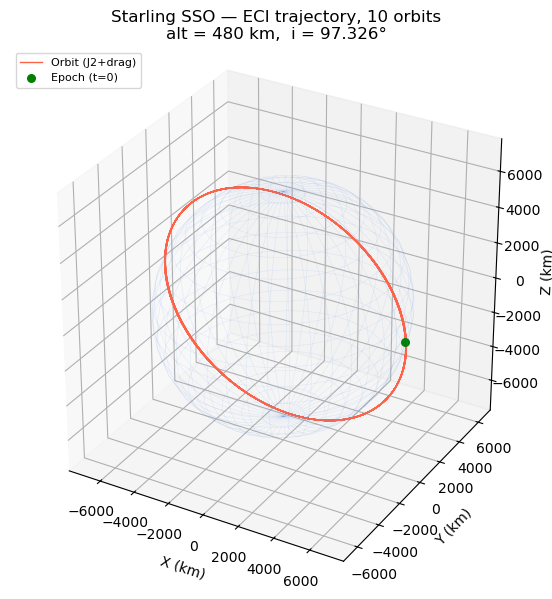

In [35]:
using PythonPlot

# --- Plot 1: 3D orbit trajectory (J2+drag, 10 orbits) ---
R2 = hcat([u[1:3] for u in sol.u]...)

fig = figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")

# Earth sphere (wireframe)
u_sph = range(0, 2π, length=40)
v_sph = range(0, π,  length=20)
Xs = [RE * cos(u)*sin(v) for u in u_sph, v in v_sph]
Ys = [RE * sin(u)*sin(v) for u in u_sph, v in v_sph]
Zs = [RE * cos(v)        for u in u_sph, v in v_sph]
ax.plot_wireframe(Xs, Ys, Zs, color="cornflowerblue", alpha=0.15, linewidth=0.4)

# Orbit trajectory
ax.plot(R2[1,:], R2[2,:], R2[3,:], color="tomato", linewidth=1.0, label="Orbit (J2+drag)")

# Mark start
ax.scatter([R2[1,1]], [R2[2,1]], [R2[3,1]], color="green", s=30, zorder=5, label="Epoch (t=0)")

ax.set_xlabel("X (km)"); ax.set_ylabel("Y (km)"); ax.set_zlabel("Z (km)")
ax.set_title("Starling SSO — ECI trajectory, 10 orbits\nalt = 480 km,  i = 97.326°")
ax.legend(loc="upper left", fontsize=8)
ax.set_box_aspect([1,1,1])
tight_layout()
savefig("figs/orbit_trajectory.png", dpi=150, bbox_inches="tight")
println("Saved figs/orbit_trajectory.png")


Saved figs/raan_precession.png


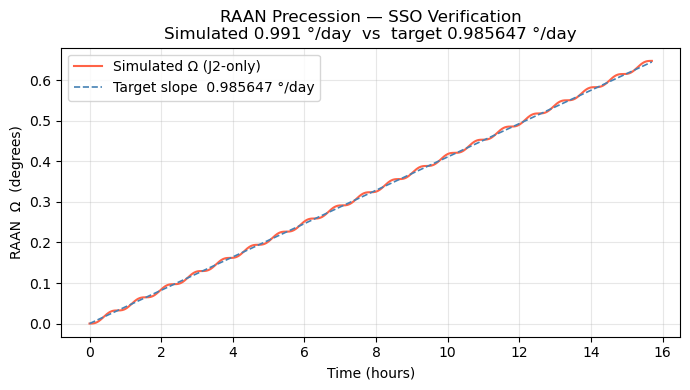

In [36]:
# --- Plot 2: RAAN vs. time  (J2-only, with target slope overlaid) ---
t_hr   = sol_j2.t ./ 3600                          # seconds → hours
Ω_deg  = rad2deg.(Ω_uw)                             # unwrapped RAAN in degrees

# Target line from Ω₀=0 at slope 0.985647 deg/day = 0.985647/24 deg/hr
target_slope_deg_hr = OMEGA_DOT_TARGET_DEG_DAY / 24
Ω_target = target_slope_deg_hr .* t_hr

fig2, ax2 = subplots(figsize=(7, 4))
ax2.plot(t_hr, Ω_deg,    color="tomato",      linewidth=1.5, label="Simulated Ω (J2-only)")
ax2.plot(t_hr, Ω_target, color="steelblue",   linewidth=1.2,
         linestyle="--", label="Target slope  $(OMEGA_DOT_TARGET_DEG_DAY) °/day")

ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("RAAN  Ω  (degrees)")
ax2.set_title("RAAN Precession — SSO Verification\nSimulated $(round(slope_deg_day, digits=4)) °/day  vs  target $(OMEGA_DOT_TARGET_DEG_DAY) °/day")
ax2.legend()
ax2.grid(true, alpha=0.3)
tight_layout()
savefig("figs/raan_precession.png", dpi=150, bbox_inches="tight")
println("Saved figs/raan_precession.png")


Saved figs/orbit_2d.png


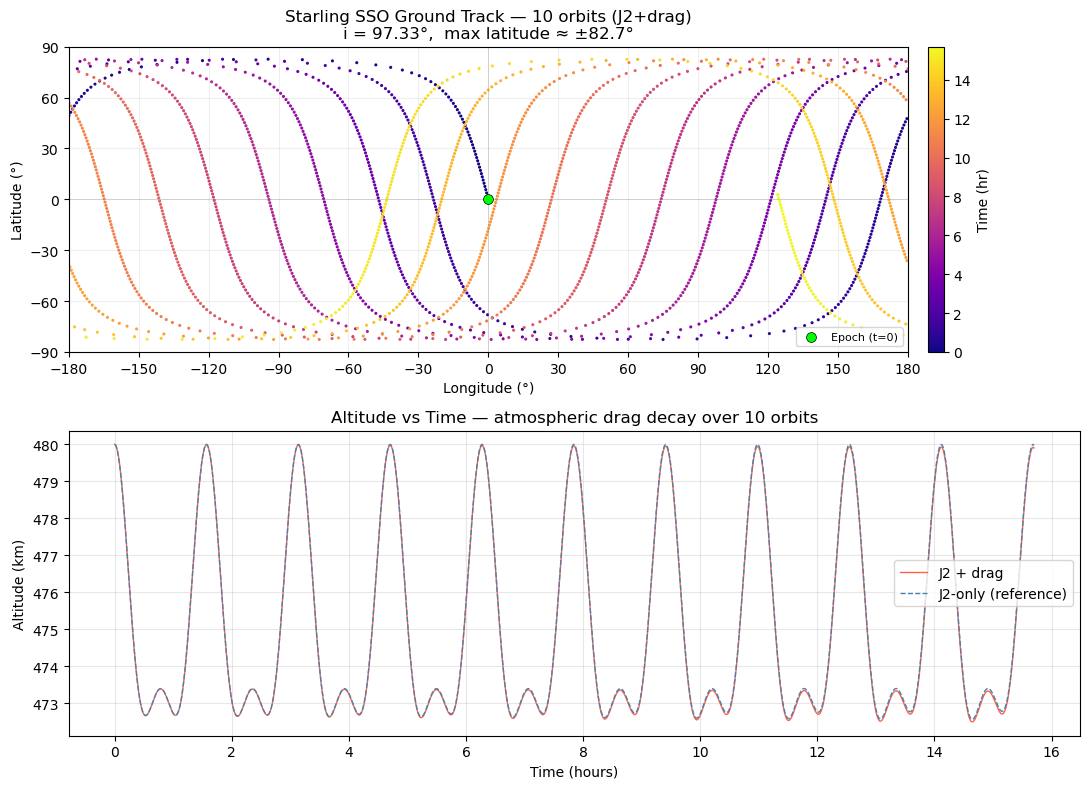

In [37]:
# --- Plot 3: Ground track + altitude vs time ---

# ECI → ECEF → geodetic lat/lon (spherical Earth, θ₀=0 at t=0)
function eci_to_latlon(r_km, t_s)
    θ     = wE * t_s
    x_ecef =  r_km[1]*cos(θ) + r_km[2]*sin(θ)
    y_ecef = -r_km[1]*sin(θ) + r_km[2]*cos(θ)
    z_ecef =  r_km[3]
    lat = rad2deg(asin(z_ecef / norm(r_km)))
    lon = rad2deg(atan(y_ecef, x_ecef))
    return lat, lon
end

lats    = [eci_to_latlon(sol.u[k][1:3], sol.t[k])[1] for k in 1:length(sol.u)]
lons    = [eci_to_latlon(sol.u[k][1:3], sol.t[k])[2] for k in 1:length(sol.u)]
alts    = [norm(sol.u[k][1:3])    - RE for k in 1:length(sol.u)]
alts_j2 = [norm(sol_j2.u[k][1:3]) - RE for k in 1:length(sol_j2.u)]

fig_2d, (ax_gt, ax_alt) = subplots(2, 1, figsize=(11, 8))

# ── Ground track ──────────────────────────────────────────────────────────────
sc = ax_gt.scatter(lons, lats;
    c=sol.t ./ 3600, cmap="plasma", s=1.5, zorder=2, rasterized=true)
fig_2d.colorbar(sc, ax=ax_gt, label="Time (hr)", pad=0.02)

ax_gt.axhline(0;  color="gray", linewidth=0.4, alpha=0.5)
ax_gt.axvline(0;  color="gray", linewidth=0.4, alpha=0.5)
ax_gt.scatter([lons[1]], [lats[1]]; color="lime", s=50, zorder=5,
    edgecolors="black", linewidths=0.5, label="Epoch (t=0)")
ax_gt.set_xlim(-180, 180);   ax_gt.set_ylim(-90, 90)
ax_gt.set_xticks(-180:30:180);  ax_gt.set_yticks(-90:30:90)
ax_gt.set_xlabel("Longitude (°)");  ax_gt.set_ylabel("Latitude (°)")
ax_gt.set_title("Starling SSO Ground Track — 10 orbits (J2+drag)\n" *
    "i = $(round(rad2deg(i_sso), digits=2))°,  max latitude ≈ ±$(round(180.0 - rad2deg(i_sso), digits=1))°")
ax_gt.legend(loc="lower right", fontsize=8);  ax_gt.grid(true, alpha=0.2)

# ── Altitude vs time ──────────────────────────────────────────────────────────
ax_alt.plot(sol.t    ./ 3600, alts,    color="tomato",    linewidth=1.0, label="J2 + drag")
ax_alt.plot(sol_j2.t ./ 3600, alts_j2, color="steelblue", linewidth=1.0,
    linestyle="--", label="J2-only (reference)")
ax_alt.set_xlabel("Time (hours)");  ax_alt.set_ylabel("Altitude (km)")
ax_alt.set_title("Altitude vs Time — atmospheric drag decay over 10 orbits")
ax_alt.legend();  ax_alt.grid(true, alpha=0.3)

tight_layout()
savefig("figs/orbit_2d.png", dpi=150, bbox_inches="tight")
println("Saved figs/orbit_2d.png")

## 8) Looping Orbit Animation (MeshCat)

In [38]:
R = hcat([u[1:3] for u in sol.u]...)
N = size(R, 2)

# Normalize to Earth-radius display units:
#   Earth sphere → radius 1.0, orbit → ~1.09 units from center
#   Without this the camera (at ~3 units) is inside the 6378-km sphere
s = 1.0 / RE

max_frames = 1200
step = max(1, cld(N, max_frames))
idx = collect(1:step:N)
xv = Float32.(R[1, idx] .* s)
yv = Float32.(R[2, idx] .* s)
zv = Float32.(R[3, idx] .* s)
M  = length(xv)

# ~943 frames at fps=20 → ~47 s playback for 10 orbits (sensible overview speed)
vis  = Visualizer()
anim = Animation(vis; fps=20)

# Earth: unit sphere with blue material
setobject!(vis[:earth],
    Sphere(Point(0.0, 0.0, 0.0), 1.0),
    MeshPhongMaterial(color=RGBA(0.2, 0.5, 1.0, 0.9)))

# Satellite: small red box (~0.05 RE ≈ 320 km display size — visible from default camera)
sat_d = 0.05
setobject!(vis[:sat],
    Rect(Vec(-sat_d/2, -sat_d/2, -sat_d/2), Vec(sat_d, sat_d, sat_d)),
    MeshPhongMaterial(color=colorant"red"))

for t = 1:M
    atframe(anim, t) do
        settransform!(vis[:sat], Translation(xv[t], yv[t], zv[t]))
    end
end

setanimation!(vis, anim; play=true, repetitions=1000000)

[ Info: Listening on: 127.0.0.1:8701, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8701


In [14]:
render(vis)

MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), UInt8[0x83, 0xa7, 0x6f, 0x70, 0x74, 0x69, 0x6f, 0x6e, 0x73, 0x82  …  0x5f, 0x61, 0x6e, 0x69, 0x6d, 0x61, 0x74, 0x69, 0x6f, 0x6e], Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("sat" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x73, 0x61, 0x74], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "earth" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x68, 0x63, 0x61, 0x74, 0x2f, 0x65, 0x61, 0x72, 0x74, 0x68], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))))), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8700, HTTP.Servers.Server{HTTP.Servers.Listener{Nothing, Sockets.TCPServer}}(HTTP.Servers.Listener{Nothing, Sockets.TCPServer}(Sockets.InetAddr{Sockets.IPv4}(ip"127.0.0.1", 8700), "127.0.0.1", "8700", nothing, Sockets.TCPServer(RawFD(52) active)), nothing, Set{HTTP.Connections.Connection}(), Task (runnable, started) @0x0000000301c1f940, ReentrantLock()), MeshCat.AnimationContext[]))

In [15]:
#okay so what do we have
#Earth Gravity
#Earth oblateness J2
#ECI Coordinates
#acc alt

#for later
#drag
#solar rad pressure
#third body consideration
#input or maneuvers

## 9) Euler's Equation — Free Tumble Dynamics

Torque-free Euler equations for Starling 6U, spun at 10 RPM about each principal axis with a small perturbation. Major and minor axes are stable; intermediate axis is unstable (tennis racket theorem).

In [39]:
# Full inertia matrix from Fusion360 CAD (body frame, includes deployed solar panels)
InertialMatrix = [
    0.282 0 0;
    0 0.188 0.028;
    0 0.028 0.174
]

# Principal moments from eigen-decomposition of InertialMatrix (Section 3.3)
I1_sc = 0.15214    # kg·m²  — minor axis   (smallest)
I2_sc = 0.20986    # kg·m²  — intermediate
I3_sc = 0.282      # kg·m²  — major axis   (largest)

J_sc = Diagonal([I1_sc, I2_sc, I3_sc])   # principal inertia tensor

println("Principal moments (kg·m²):")
println("  I1 minor        = $I1_sc")
println("  I2 intermediate = $I2_sc")
println("  I3 major        = $I3_sc")


Principal moments (kg·m²):
  I1 minor        = 0.15214
  I2 intermediate = 0.20986
  I3 major        = 0.282


In [40]:
# Quaternion helpers (matching lecture notation: tumble.ipynb)
hat(v) = [0 -v[3] v[2]; v[3] 0 -v[1]; -v[2] v[1] 0]
const H = [zeros(1,3); I(3)]
L(q) = [q[1] -q[2:4]'; q[2:4] q[1]*I(3) + hat(q[2:4])]
R_quat(q) = [q[1] -q[2:4]'; q[2:4] q[1]*I(3) - hat(q[2:4])]
G(q) = L(q)*H

# Rotation matrix from quaternion (body → inertial): Q = H'*L(q)*R_quat(q)'*H
Q_rot(q) = H'*L(q)*R_quat(q)'*H

# 7-state ODE: x = [q(4); ω(3)], p = (I1, I2, I3)
function euler_ode!(dx, x, p, t)
    I1, I2, I3 = p
    q = x[1:4] ./ norm(x[1:4])
    ω = x[5:7]
    dx[1:4] .= 0.5*G(q)*ω               # quaternion kinematics
    dx[5]    = (I2 - I3)/I1 * ω[2]*ω[3] # Euler axis 1
    dx[6]    = (I3 - I1)/I2 * ω[3]*ω[1] # Euler axis 2
    dx[7]    = (I1 - I2)/I3 * ω[1]*ω[2] # Euler axis 3
end

# Re-normalize quaternion after each accepted step
function normalize_quat!(integrator)
    integrator.u[1:4] ./= norm(integrator.u[1:4])
end
const q_norm_cb = DiscreteCallback((u, t, integrator) -> true, normalize_quat!;
    save_positions=(false, false))

rpm2rad(r) = r * 2π / 60


rpm2rad (generic function with 1 method)

In [41]:
wmag = rpm2rad(10.0)                    # 10 RPM in rad/s
H0   = I3_sc * wmag                    # angular momentum magnitude (from major axis)
q0   = [1.0, 0.0, 0.0, 0.0]           # identity quaternion

err_stable = rpm2rad(2.0)   # 20% — large enough to show visible loops on momentum sphere
err_inter  = rpm2rad(0.05)  # 0.5% — small, traces the separatrix cleanly

ω_major = [0.0,       0.0,       H0/I3_sc]
ω_inter = [0.0,       H0/I2_sc,  0.0     ]
ω_minor = [H0/I1_sc,  0.0,       0.0     ]

ω_major_p = ω_major + [err_stable, 0.0,       0.0      ]
ω_inter_p = ω_inter + [0.0,        0.0,       err_inter]
ω_minor_p = ω_minor + [0.0,        err_stable, 0.0     ]

p_euler = (I1_sc, I2_sc, I3_sc)
tspan_e = (0.0, 600.0)    # 10 min

function euler_sim(ω0)
    x0 = [q0; ω0]
    prob = ODEProblem(euler_ode!, x0, tspan_e, p_euler)
    solve(prob, Vern9(); callback=q_norm_cb, reltol=1e-10, abstol=1e-12, saveat=0.1)
end

sol_major_e = euler_sim(ω_major_p)
sol_inter_e = euler_sim(ω_inter_p)
sol_minor_e = euler_sim(ω_minor_p)

println("Steps — major: $(length(sol_major_e)), inter: $(length(sol_inter_e)), minor: $(length(sol_minor_e))")

Steps — major: 6001, inter: 6001, minor: 6001


Saved figs/euler_conservation.png


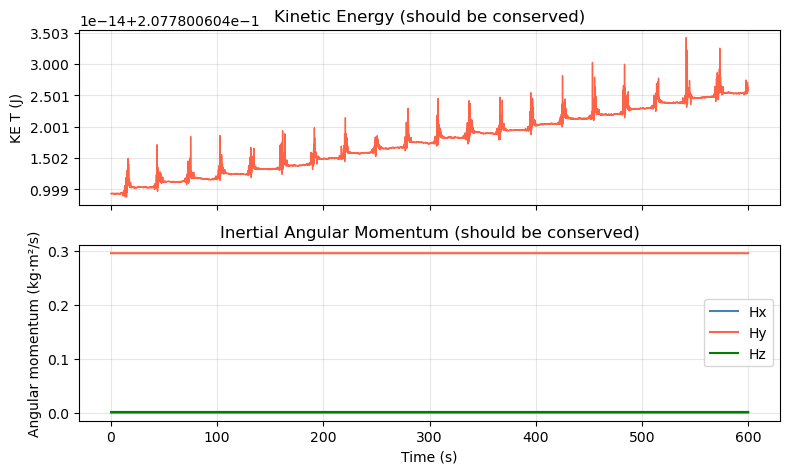

In [42]:
# Conservation plots: kinetic energy T(t) + inertial angular momentum hn(t)
# Uses intermediate-axis solution (separatrix behavior)
n_e   = length(sol_inter_e)
T_e   = [0.5*sol_inter_e[5:7,k]'*J_sc*sol_inter_e[5:7,k] for k in 1:n_e]
hn_e  = hcat([Q_rot(sol_inter_e[1:4,k])*(J_sc*sol_inter_e[5:7,k]) for k in 1:n_e]...)

fig3, (ax3a, ax3b) = subplots(2,1, figsize=(8,5), sharex=true)
ax3a.plot(sol_inter_e.t, T_e, color="tomato", linewidth=1)
ax3a.set_ylabel("KE T (J)");  ax3a.set_title("Kinetic Energy (should be conserved)")
ax3a.grid(true, alpha=0.3)

ax3b.plot(sol_inter_e.t, hn_e[1,:], label="Hx", color="steelblue")
ax3b.plot(sol_inter_e.t, hn_e[2,:], label="Hy", color="tomato")
ax3b.plot(sol_inter_e.t, hn_e[3,:], label="Hz", color="green")
ax3b.set_xlabel("Time (s)");  ax3b.set_ylabel("Angular momentum (kg·m²/s)")
ax3b.set_title("Inertial Angular Momentum (should be conserved)")
ax3b.legend();  ax3b.grid(true, alpha=0.3)
tight_layout()
savefig("figs/euler_conservation.png", dpi=150, bbox_inches="tight")
println("Saved figs/euler_conservation.png")

Saved figs/momentum_sphere.png


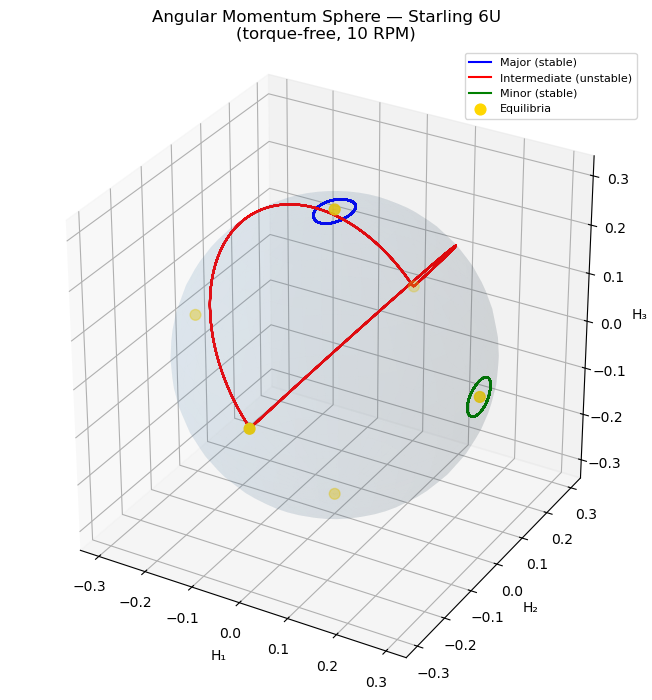

In [43]:
# Momentum sphere (PythonPlot 3D)
# H trajectories in body (principal) frame
function H_hist(sol)
    hcat([[I1_sc*sol[5,k], I2_sc*sol[6,k], I3_sc*sol[7,k]] for k in 1:length(sol)]...)
end

Hm    = H_hist(sol_major_e)
Hi    = H_hist(sol_inter_e)
Hn_s  = H_hist(sol_minor_e)

Hnorm = norm(Hm[:,1])    # = H0

# 6 equilibrium points on sphere
eq_pts = Hnorm*[1 -1 0  0  0  0;
                0  0 1 -1  0  0;
                0  0 0  0  1 -1]

# Sphere surface
u_s = range(0, 2π, length=50);  v_s = range(0, π, length=25)
Hsx = Hnorm .* [cos(u)*sin(v) for u in u_s, v in v_s]
Hsy = Hnorm .* [sin(u)*sin(v) for u in u_s, v in v_s]
Hsz = Hnorm .* [cos(v)        for u in u_s, v in v_s]

fig4 = figure(figsize=(7,7))
ax4  = fig4.add_subplot(111, projection="3d")
ax4.plot_surface(Hsx, Hsy, Hsz; alpha=0.08, color="steelblue")
ax4.plot(Hm[1,:],   Hm[2,:],   Hm[3,:];   color="blue",  linewidth=1.5, label="Major (stable)")
ax4.plot(Hi[1,:],   Hi[2,:],   Hi[3,:];   color="red",   linewidth=1.5, label="Intermediate (unstable)")
ax4.plot(Hn_s[1,:], Hn_s[2,:], Hn_s[3,:]; color="green", linewidth=1.5, label="Minor (stable)")
ax4.scatter(eq_pts[1,:], eq_pts[2,:], eq_pts[3,:]; s=60, color="gold", zorder=5, label="Equilibria")
ax4.set_xlabel("H₁");  ax4.set_ylabel("H₂");  ax4.set_zlabel("H₃")
ax4.set_title("Angular Momentum Sphere — Starling 6U\n(torque-free, 10 RPM)")
ax4.legend(fontsize=8)
ax4.set_box_aspect([1,1,1])
tight_layout()
savefig("figs/momentum_sphere.png", dpi=150, bbox_inches="tight")
println("Saved figs/momentum_sphere.png")

Saved figs/euler_omega.png + figs/euler_perturbations.png


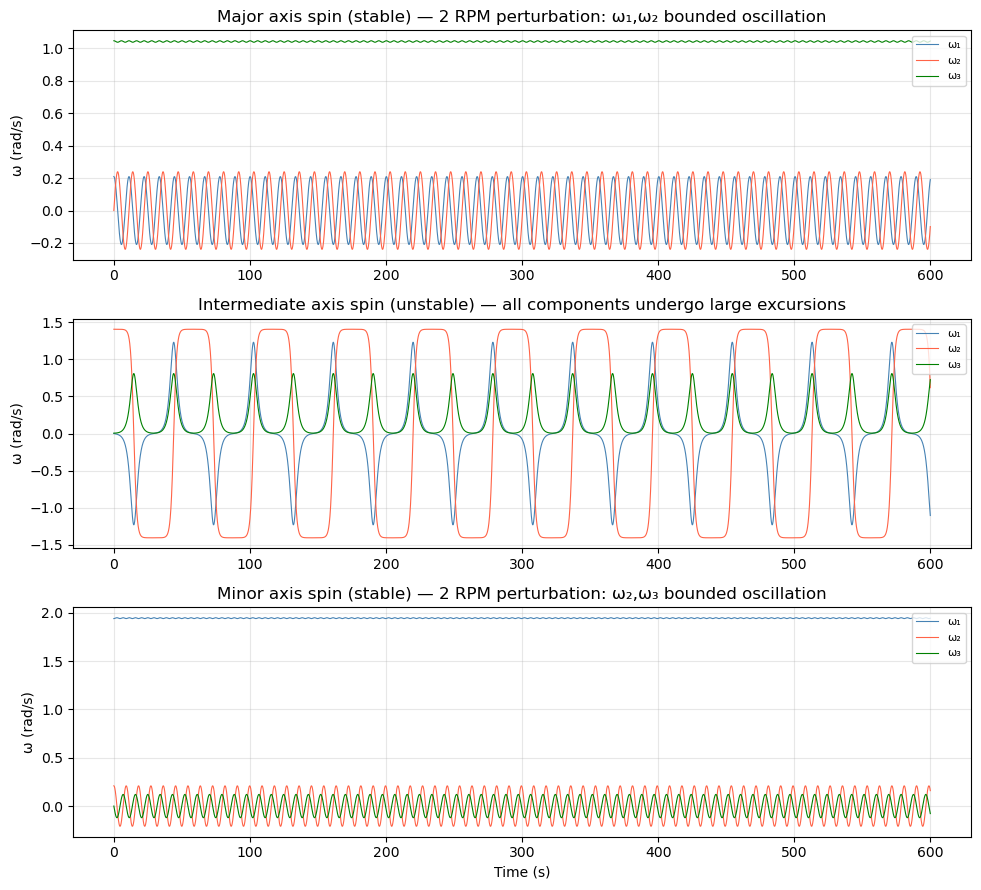

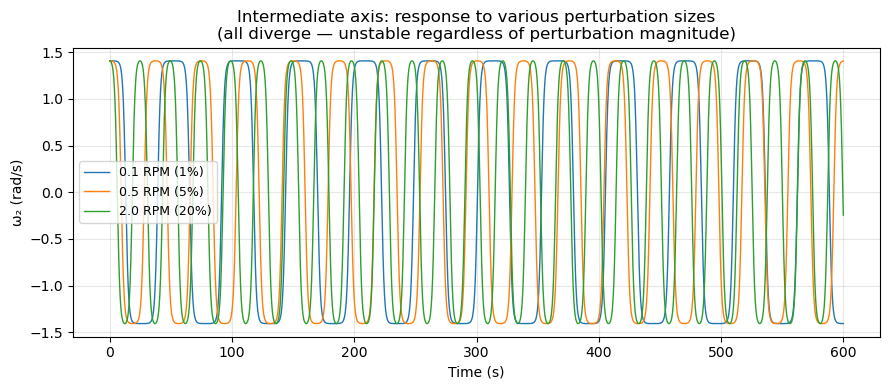

In [44]:
# ── Plot 1: ω(t) time histories for all three spin cases ──────────────────────
fig5, (ax5a, ax5b, ax5c) = subplots(3, 1, figsize=(10, 9), sharex=false)

# Major axis (stable)
ax5a.plot(sol_major_e.t, sol_major_e[5,:], color="steelblue", linewidth=0.8, label="ω₁")
ax5a.plot(sol_major_e.t, sol_major_e[6,:], color="tomato",    linewidth=0.8, label="ω₂")
ax5a.plot(sol_major_e.t, sol_major_e[7,:], color="green",     linewidth=0.8, label="ω₃")
ax5a.set_ylabel("ω (rad/s)")
ax5a.set_title("Major axis spin (stable) — 2 RPM perturbation: ω₁,ω₂ bounded oscillation")
ax5a.legend(loc="upper right", fontsize=8);  ax5a.grid(true, alpha=0.3)

# Intermediate axis (unstable — separatrix)
ax5b.plot(sol_inter_e.t, sol_inter_e[5,:], color="steelblue", linewidth=0.8, label="ω₁")
ax5b.plot(sol_inter_e.t, sol_inter_e[6,:], color="tomato",    linewidth=0.8, label="ω₂")
ax5b.plot(sol_inter_e.t, sol_inter_e[7,:], color="green",     linewidth=0.8, label="ω₃")
ax5b.set_ylabel("ω (rad/s)")
ax5b.set_title("Intermediate axis spin (unstable) — all components undergo large excursions")
ax5b.legend(loc="upper right", fontsize=8);  ax5b.grid(true, alpha=0.3)

# Minor axis (stable)
ax5c.plot(sol_minor_e.t, sol_minor_e[5,:], color="steelblue", linewidth=0.8, label="ω₁")
ax5c.plot(sol_minor_e.t, sol_minor_e[6,:], color="tomato",    linewidth=0.8, label="ω₂")
ax5c.plot(sol_minor_e.t, sol_minor_e[7,:], color="green",     linewidth=0.8, label="ω₃")
ax5c.set_ylabel("ω (rad/s)");  ax5c.set_xlabel("Time (s)")
ax5c.set_title("Minor axis spin (stable) — 2 RPM perturbation: ω₂,ω₃ bounded oscillation")
ax5c.legend(loc="upper right", fontsize=8);  ax5c.grid(true, alpha=0.3)

tight_layout()
savefig("figs/euler_omega.png", dpi=150, bbox_inches="tight")

# ── Plot 2: intermediate axis — various perturbation sizes (all diverge) ──────
err_vals = [rpm2rad(0.1), rpm2rad(0.5), rpm2rad(2.0)]
labels_p = ["0.1 RPM (1%)", "0.5 RPM (5%)", "2.0 RPM (20%)"]
cols_p   = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig6, ax6 = subplots(figsize=(9, 4))
for (err_v, lbl, c) in zip(err_vals, labels_p, cols_p)
    sol_p = euler_sim([0.0, H0/I2_sc, err_v])
    ax6.plot(sol_p.t, sol_p[6,:], color=c, linewidth=1.0, label=lbl)
end
ax6.set_xlabel("Time (s)");  ax6.set_ylabel("ω₂ (rad/s)")
ax6.set_title("Intermediate axis: response to various perturbation sizes\n(all diverge — unstable regardless of perturbation magnitude)")
ax6.legend(fontsize=9);  ax6.grid(true, alpha=0.3)
tight_layout()
savefig("figs/euler_perturbations.png", dpi=150, bbox_inches="tight")

println("Saved figs/euler_omega.png + figs/euler_perturbations.png")

In [45]:
# ── Analytical nutation frequencies from linearized Euler equations ───────────
#
#  Spin about axis k, small perturbations on i,j:
#    ω_n = Ω_k * sqrt( (Ik - Ii)(Ik - Ij) / (Ii * Ij) )
#  Real → stable when Ik is the largest or smallest moment.

Ω_major = H0 / I3_sc        # = wmag  (spin rate about major axis)
Ω_minor = H0 / I1_sc        # higher — same H0 but smallest inertia

Ω_n_major = Ω_major * sqrt((I3_sc - I2_sc)*(I3_sc - I1_sc) / (I1_sc * I2_sc))
Ω_n_minor = Ω_minor * sqrt((I2_sc - I1_sc)*(I3_sc - I1_sc) / (I2_sc * I3_sc))

T_n_major_theory = 2π / Ω_n_major
T_n_minor_theory = 2π / Ω_n_minor

# ── Extract simulated period via zero-crossings of the perturbed component ────
function nutation_period(y, t)
    yc = y .- mean(y)                 # remove mean (handles nonzero offset)
    crossings = Float64[]
    for k in 2:length(yc)
        if yc[k-1] * yc[k] < 0       # sign change → zero crossing
            t_c = t[k-1] + (t[k]-t[k-1]) * abs(yc[k-1]) / (abs(yc[k-1]) + abs(yc[k]))
            push!(crossings, t_c)
        end
    end
    length(crossings) < 4 && return NaN
    return 2 * mean(diff(crossings))  # 2 × mean half-period
end

# Major: ω₁ is the perturbed (off-axis) component
T_major_sim = nutation_period(sol_major_e[5,:], sol_major_e.t)
# Minor: ω₂ is the perturbed component
T_minor_sim = nutation_period(sol_minor_e[6,:], sol_minor_e.t)

# ── Conservation quality from Cell E (T_e, hn_e already computed) ─────────────
T_e_dev   = maximum(abs.(T_e   .- T_e[1]))   / T_e[1]   * 100
H_e_norms = [norm(hn_e[:,k]) for k in 1:size(hn_e,2)]
H_e_dev   = maximum(abs.(H_e_norms .- H_e_norms[1])) / H_e_norms[1] * 100

println("  NUTATION PERIOD VALIDATION")
println("Major axis (I₃ = $(round(I3_sc,digits=4)) kg·m², spin = $(round(Ω_major,digits=4)) rad/s):")
println("  Theory (linearized):  Tₙ = $(round(T_n_major_theory, digits=3)) s")
println("  Simulated (zero-xing):Tₙ = $(round(T_major_sim,      digits=3)) s")
println("  Error:                    $(round(abs(T_major_sim - T_n_major_theory)/T_n_major_theory*100, digits=2)) %")
println()
println("Minor axis (I₁ = $(round(I1_sc,digits=4)) kg·m², spin = $(round(Ω_minor,digits=4)) rad/s):")
println("  Theory (linearized):  Tₙ = $(round(T_n_minor_theory, digits=3)) s")
println("  Simulated (zero-xing):Tₙ = $(round(T_minor_sim,      digits=3)) s")
println("  Error:                    $(round(abs(T_minor_sim - T_n_minor_theory)/T_n_minor_theory*100, digits=2)) %")
println()
println("  Max |ΔT / T₀|  = $(round(T_e_dev,   sigdigits=2)) %")
println("  Max |ΔH / H₀|  = $(round(H_e_dev,   sigdigits=2)) %")

  NUTATION PERIOD VALIDATION
Major axis (I₃ = 0.282 kg·m², spin = 1.0472 rad/s):
  Theory (linearized):  Tₙ = 11.077 s
  Simulated (zero-xing):Tₙ = 11.125 s
  Error:                    0.44 %

Minor axis (I₁ = 0.1521 kg·m², spin = 1.941 rad/s):
  Theory (linearized):  Tₙ = 9.096 s
  Simulated (zero-xing):Tₙ = 9.076 s
  Error:                    0.22 %

  Max |ΔT / T₀|  = 1.2e-11 %
  Max |ΔH / H₀|  = 2.1e-11 %


In [46]:
# MeshCat tumbling animation — intermediate-axis spin (most dramatic)
# swap to sol_major_e or sol_minor_e to see stable spin
sol_e_anim = sol_inter_e

N_e   = length(sol_e_anim)
idx_e = 1:N_e   # use all frames — 6001 pts at 0.1 s each

# fps=60 + 0.1 s/frame → 6°/frame at 10 RPM → smooth
# Total: 6001 frames / 60 fps = 100 s playback (6× real-time)
vis2  = Visualizer()
anim2 = Animation(vis2; fps=60)

# 6U CubeSat box: 100mm × 200mm × 300mm
# Simplified geometry — deployed solar panels not shown visually,
# but their mass/inertia is included in the CAD-derived inertia matrix (Section 3.2)
setobject!(vis2[:sc],
    Rect(Vec(-0.05, -0.10, -0.15), Vec(0.10, 0.20, 0.30)),
    MeshPhongMaterial(color=RGBA(0.6, 0.75, 0.95, 1.0)))

for (frame, k) in enumerate(idx_e)
    q = sol_e_anim[1:4, k]
    q ./= norm(q)
    atframe(anim2, frame) do
        settransform!(vis2[:sc], LinearMap(QuatRotation(q[1], q[2], q[3], q[4])))
    end
end
setanimation!(vis2, anim2; play=true, repetitions=1000000)

[ Info: Listening on: 127.0.0.1:8702, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8702


In [47]:
render(vis2)

MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), UInt8[0x83, 0xa7, 0x6f, 0x70, 0x74, 0x69, 0x6f, 0x6e, 0x73, 0x82  …  0x5f, 0x61, 0x6e, 0x69, 0x6d, 0x61, 0x74, 0x69, 0x6f, 0x6e], Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("sc" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x6d, 0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x73, 0x63], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))))), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8702, HTTP.Servers.Server{HTTP.Servers.Listener{Nothing, Sockets.TCPServer}}(HTTP.Servers.Listener{Nothing, Sockets.TCPServer}(Sockets.InetAddr{Sockets.IPv4}(ip"127.0.0.1", 8702), "127.0.0.1", "8702", nothing, Sockets.TCPServer(RawFD(58) active)), nothing, Set{HTTP.Connections.Connection}(), Task (runnable, started) @0x000000033fa39e10, ReentrantLock()), MeshCat.AnimationContext[]))